# **CV #1: Image Enhancement**

by **R. Ethan Halim** (CS-A 2024, 536718)

## Auxiliary Preface

This assignment primarily uses [numpy](https://numpy.org) for array computations and [matplotlib](http://matplotlib.org) for visualizations. This notebook requires a Python environment of at least version 3.10 (with the addition of `match` statements). Below are the imports as well as a couple of auxiliary functions.

In [1]:
import numpy as np
import matplotlib.axes
import matplotlib.pyplot as plt


## Helper function to display text-image pairs side-by-side easily
def display(*images: tuple[str, np.ndarray]):
    _, axes = plt.subplots(1, len(images), figsize=(10, 5))
    if isinstance(axes, matplotlib.axes.Axes): # If only one
        axes: list[matplotlib.axes.Axes] = [axes]

    for i, (title, image) in enumerate(images):
        axes[i].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
        axes[i].set_title(title)
        axes[i].axis("off")

    plt.show()


## Helper function to load image in grayscale, no matter the format
def load_grayscale(file: str) -> np.ndarray:
    image = plt.imread(file)
    if image.dtype == np.uint8:
        image = image / 255.0 # Normalizes within 0.0-1.0

    match len(image.shape):
        case 2: # Already grayscale
            return image
        case 3:
            match image.shape[2]:
                case 3: # RGB
                    return image @ (0.2989, 0.5870, 0.1140)
                case 4: # RGBA
                    return image[..., :3] @ (0.2989, 0.5870, 0.1140) * image[..., 3]
                case _:
                    assert False
        case _:
            assert False

## Original Images

Below, I acquired two grayscale images of the same reptilian subject, which were:

- **too dark** and **low contrast** (left);
- as well as **too bright** (right).

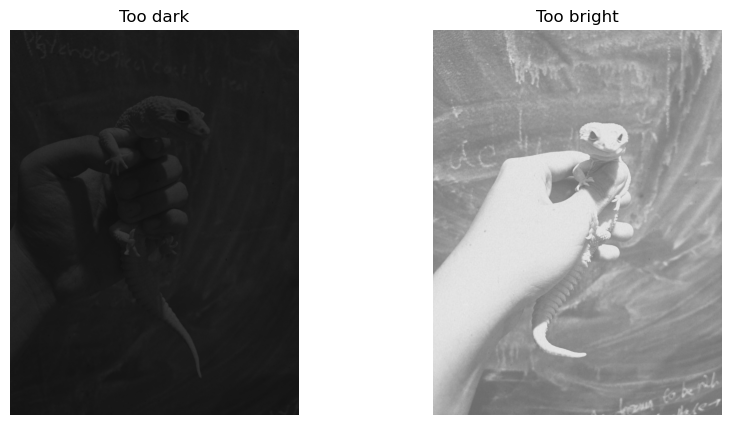

In [2]:
too_dark = load_grayscale("too_dark.png")
too_bright = load_grayscale("too_bright.png")
display(("Too dark", too_dark), ("Too bright", too_bright))

## Contrast Enhancement

In order to improve the clarity of the two images, their per-pixel contrast is to be enhanced.

### Logarithmic Transformation

Logarithmic transformation works by passing each pixel ($r$) through a $\log$ function of a certain base ($b$).

$$T(r) = c \cdot \log_b(1 + r) = c \cdot \frac{\log(1 + r)}{\log(b)}$$

In the case below, I've implemented the formula as a function to apply several bases. The image has already been normalized between 0.0-1.0, thus $c$ is omitted.

In [3]:
def log_transform(image: np.ndarray, bases: list[float]) -> list[tuple[str, np.ndarray]]:
    return [
        (
            f"log{b}(1 + image)",
            np.log(1 + image) / np.log(b) # Actual formula
        )
        for b in bases
    ]

As can be seen below, the logarithmic transformation works well with the image that was **too dark**, where $b \approx 1.2$ provided the most visual clarity and contrast by eye. However, as for the image that was **too bright**, it worsened the overall image, as it merely darkens everything evenly without improving contrast.

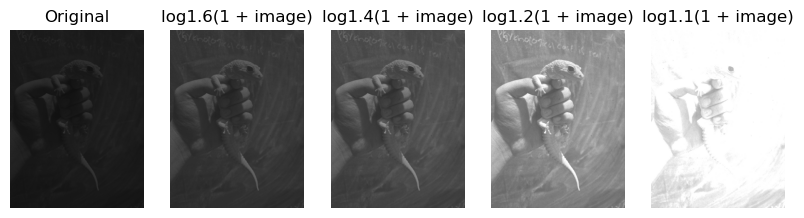

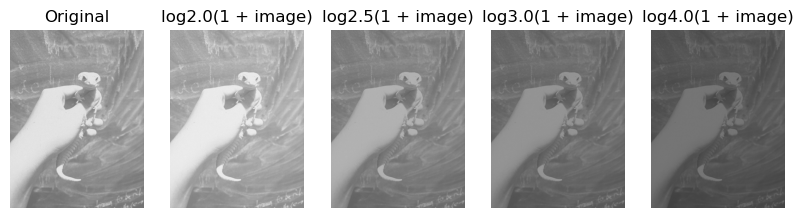

In [4]:
display(*([("Original", too_dark)] + log_transform(too_dark, [1.6, 1.4, 1.2, 1.1])))
display(*([("Original", too_bright)] + log_transform(too_bright, [2.0, 2.5, 3.0, 4.0])))

### Exponential Transformation

Exponential transformation works by exponentiating each pixel ($r$) with a certain exponent ($\gamma$).

$$T(r) = c \cdot r^\gamma$$

In the case below, I've implemented the formula as a function to apply several exponents. The image has already been normalized between 0.0-1.0, thus $c$ is omitted.

In [5]:
def exp_transform(image: np.ndarray, exponents: list[float]) -> list[tuple[str, np.ndarray]]:
    return [
        (
            f"image^{exponent}",
            image ** exponent # Actual formula
        )
        for exponent in exponents
    ]

Exponential transformation had the opposite potency of logarithmic transformation. As can be seen below, it suboptimally enhanced the image that was **too dark**, where the most visual clarity could be observed where $\gamma \approx 0.6$. However, as for the image that was **too bright**, it improved the contrast, where $\gamma \approx 2.0$ provided the most clarity by eye.

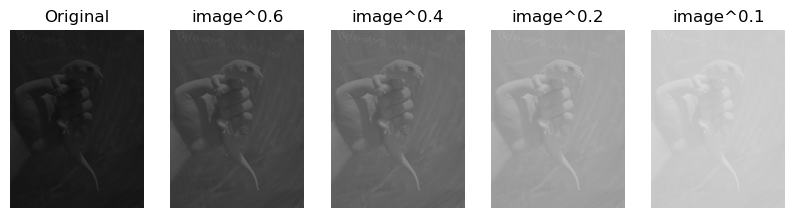

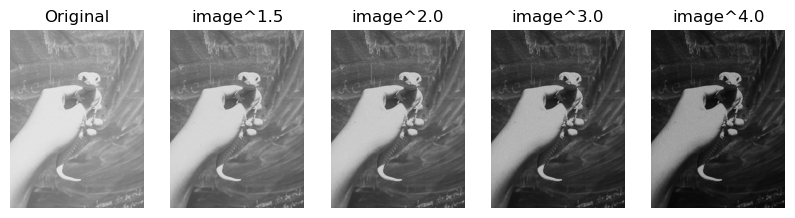

In [6]:
display(*([("Original", too_dark)] + exp_transform(too_dark, [0.6, 0.4, 0.2, 0.1])))
display(*([("Original", too_bright)] + exp_transform(too_bright, [1.5, 2.0, 3.0, 4.0])))

### Contrast Stretching

Contrast stretching works by linearly stretching the range of each pixel to the colorspace based on the minimum and maximum values of all pixels.

$$T(r) = (r - \text{Min})\frac{b - a}{\text{Max} - \text{Min}} + a = \frac{r - \text{Min}}{\text{Max} - \text{Min}}$$

It is implemented as is as a single function below. This image has already been normalized between 0.0-1.0, thus $a$ (0.0) and $b$ (1.0) are omitted.

In [7]:
def contrast_stretch(image: np.ndarray) -> np.ndarray:
    minimum, maximum = np.min(image), np.max(image)
    print(f"Stretching {minimum} - {maximum} to 0.0 - 1.0...")
    return (image - minimum) / (maximum - minimum) # Actual formula

As can be seen below, it improved both the visual clarity and contrast of both images.

Stretching 0.06273882723972202 - 0.23134941287487745 to 0.0 - 1.0...


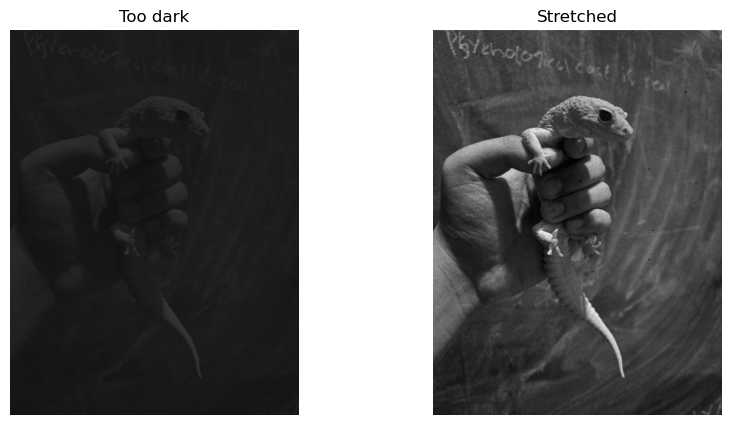

Stretching 0.41956588714420795 - 0.9175552990257739 to 0.0 - 1.0...


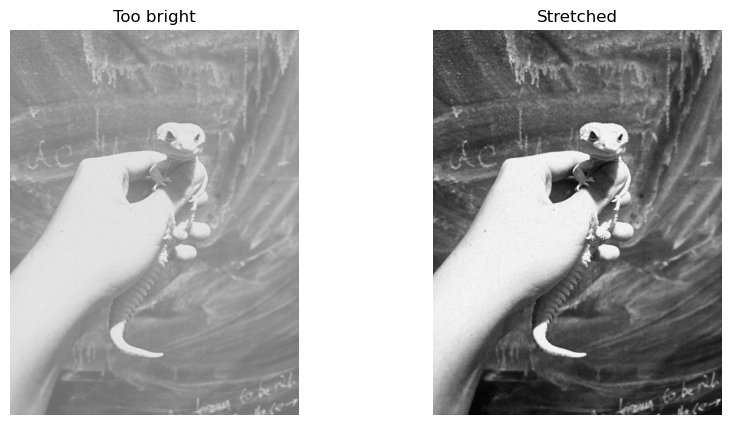

In [8]:
display(("Too dark", too_dark), ("Stretched", contrast_stretch(too_dark)))
display(("Too bright", too_bright), ("Stretched", contrast_stretch(too_bright)))

### Histogram Equalization

Historical equalization works by mapping each pixel to with the cumulative distribution value (from the CDF) of the pixel value in the overall image, obtained from the probability distribution function (PDF). In this case, I denormalized it to the integer range 0-255 to obtain each probability value discretely.

$$
\begin{cases}
\text{PDF}(v) = \frac{\text{\# of } v \text{ in the image}}{\text{image width} \cdot \text{height}} \\
\text{CDF}(v) = \sum_{i = 0}^{v} \text{PDF}(v) \text{, or when v > 0, } \text{CDF}(v - 1) + \text{PDF}(v)\\
T(r) = \text{CDF}(\text{floor}(255 \cdot r))
\end{cases}
$$

Below, I have implemented $\text{PDF}(v)$ inside of `get_image_pdf` and $\text{CDF}(v)$ & $T(r)$ inside of `equalize_histogram`.

In [9]:
def get_image_pdf(mapped: np.ndarray) -> np.ndarray:
    mapped = np.array(mapped * 255, dtype=np.uint8)
    samples = mapped.shape[0] * mapped.shape[1]

    # Computes the probability distribution function PDF(v), where 0 <= v <= 255
    pdf = np.zeros(256, dtype=np.float32)
    for intensity, count in zip(*np.unique(mapped, return_counts=True)):
        pdf[intensity] = count / samples # Actual formula

    return pdf


def equalize_histogram(image: np.ndarray) -> np.ndarray:
    pdf = get_image_pdf(image)

    # Computes the cumulative distribution function CDF(v), where 0 <= v <= 255
    cdf = np.zeros(256, dtype=np.float32)
    for intensity, probability in enumerate(pdf):
        cdf[intensity] = cdf[intensity - 1] + probability # Actual formula

    return np.vectorize(lambda p: cdf[int(p * 255)])(image) # Actual formula

As can be visualized and seen below, the technique improved the clarity and contrast of both images. As how the histograms visualize (plotting $\text{PDF}(v)$), it spreads out the distribution over the colorspace, showing that areas with higher probabilities get spread out over a larger area in the resulting images.

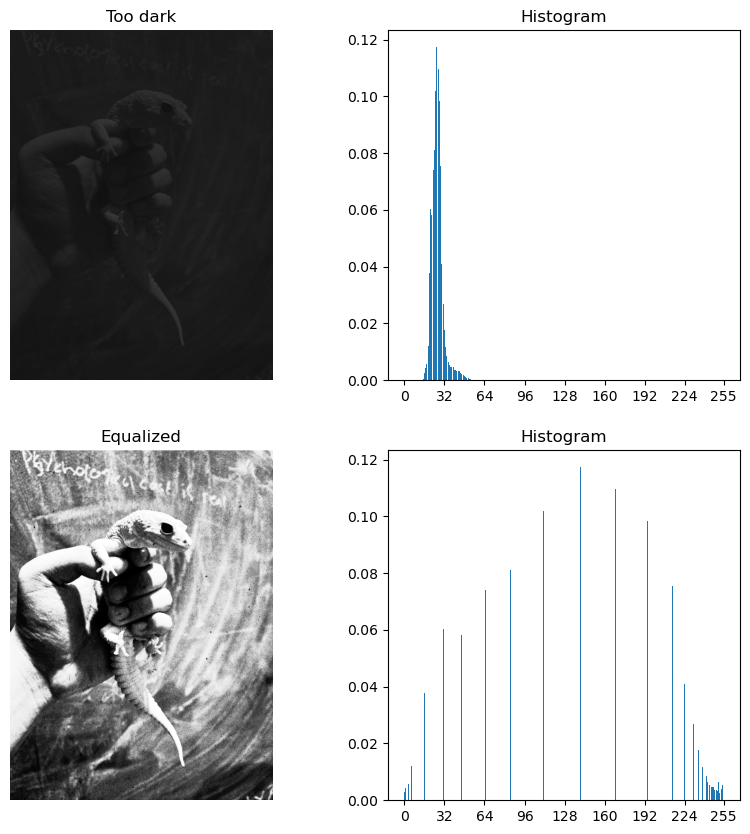

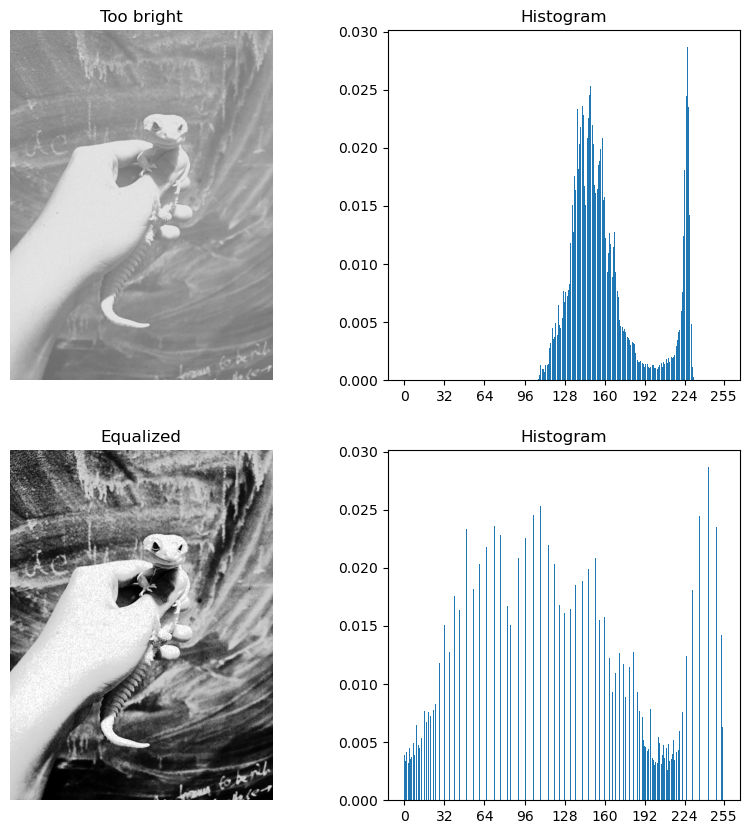

In [10]:
dark_pdf = get_image_pdf(too_dark)
equalized_dark = equalize_histogram(too_dark)
equalized_dark_pdf = get_image_pdf(equalized_dark)

bright_pdf = get_image_pdf(too_bright)
equalized_bright = equalize_histogram(too_bright)
equalized_bright_pdf = get_image_pdf(equalized_bright)

# Arranges each version with its histogram
for version in ((("Too dark", too_dark, dark_pdf), ("Equalized", equalized_dark, equalized_dark_pdf)),
                (("Too bright", too_bright, bright_pdf), ("Equalized", equalized_bright, equalized_bright_pdf))):
    _, axes = plt.subplots(len(version), 2, figsize=(10, 10))
    for i, (name, image, pdf) in enumerate(version):
        axes[i][0].set_title(name)
        axes[i][0].imshow(image, cmap="gray", vmin=0.0, vmax=1.0)
        axes[i][0].axis("off")
        axes[i][1].set_title("Histogram")
        axes[i][1].bar([i for i in range(256)], pdf)
        axes[i][1].set_xticks([*range(0, 256, 32), 255])
    plt.show()